In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

## Objective

**Predicting Freight Cost** for a vendor invoice using quantity and dollars, to improve cast forecasting, budgeting and vendor negotiation.

- Freight costs are the total expenses incurred to transport goods from origin to destination. They encompass base transportation rates, fuel surcharges, terminal handling fees, and insurance.

#### Calculation of freight cost
* Quite complex and requires real effort.

#### Reason for correct estimation
* poor freight cost estimation can damage the margin and inventory planning
* Estimating freight cost can helps teams forecast true cost before invoice arrival.

**Regression model for price estimation**


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Establish Connection with the database
conn = sqlite3.connect('/content/drive/MyDrive/inventory.db')

In [4]:
# Fetch all the tables
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'", conn)
print(tables)

              name
0        purchases
1  purchase_prices
2   vendor_invoice
3  begin_inventory
4    end_inventory


In [5]:
for table in tables['name']:
    print('Table name:', table)
    df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn)
    display(df)

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


For the prediction of **"freight cost"** we will be using **vendor_invoice**.


In [6]:
vendor_df = pd.read_sql_query("SELECT * FROM vendor_invoice", conn)
vendor_df.head(5)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


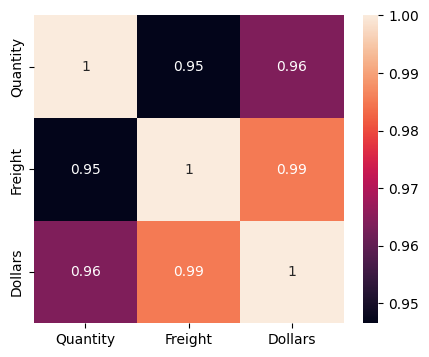

In [7]:
# Correlation b/w factors deciding freight cost
plt.figure(figsize=(5,4))
sns.heatmap(vendor_df[['Quantity', 'Freight', 'Dollars']].corr(), annot=True)
plt.show()

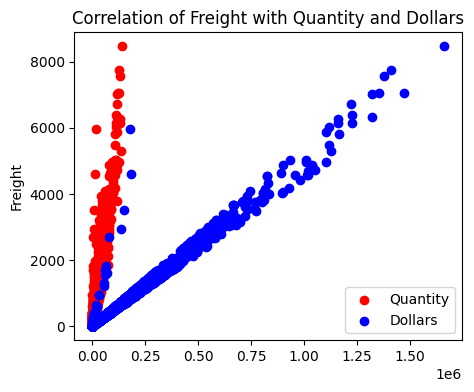

In [8]:
plt.figure(figsize=(5,4))
plt.scatter(vendor_df['Quantity'], vendor_df['Freight'], color='red')
plt.scatter(vendor_df['Dollars'], vendor_df['Freight'], color='blue')
plt.title("Correlation of Freight with Quantity and Dollars")
plt.ylabel("Freight")
plt.legend(['Quantity', 'Dollars'])
plt.show()

#### Analysing the Freight cost per unit


In [9]:
vendor_df['Freight_cost_per_unit'] = vendor_df['Freight']/ vendor_df['Quantity']
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [10]:
vendor_df[vendor_df['Quantity'] < low_quantity]['Freight_cost_per_unit'].mean()

np.float64(0.09489854253138316)

In [11]:
vendor_df[vendor_df['Quantity'] > high_quantity]['Freight_cost_per_unit'].mean()

np.float64(0.049077654690759046)

The Frieght cost is inversely proportional to the quanity, higher the quantity will be lower the invoice charge.

#### Analysing the Frieght cost per Dollars

In [32]:
vendor_df['Freight_cost_per_dollar'] = vendor_df['Freight']/ vendor_df['Dollars']
low_dollars = vendor_df['Dollars'].quantile(0.25)
high_dollars = vendor_df['Dollars'].quantile(0.75)

In [33]:
vendor_df[vendor_df['Dollars'] < low_dollars]['Freight_cost_per_dollar'].mean()

np.float64(0.006169780245753802)

In [34]:
vendor_df[vendor_df['Dollars'] > high_dollars]['Freight_cost_per_dollar'].mean()

np.float64(0.0051625235941387)

The Frieght cost is inversely proportional to the Dollars, higher the Dollars will be lower the invoice charge.

#### Training the model

In [58]:
X = vendor_df[['Dollars']]
Y = vendor_df['Freight']

In [59]:
# Outliers
vendor_df[['Quantity', 'Dollars', 'Freight']].describe().round(2)

,Quantity,Dollars,Freight
count,5543.00,5543.00,5543.00
mean,6058.88,58073.38,295.95
std,14453.34,140234.03,713.59
min,1.00,4.14,0.02
25%,83.00,967.81,5.02
50%,423.00,4765.45,24.73
75%,5100.50,44587.18,229.66
max,141660.00,1660435.88,8468.22


In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state=42)

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [63]:
m1 = LinearRegression()
m1.fit(X_train, y_train)

m2 = DecisionTreeRegressor()
m2.fit(X_train, y_train)

m3 = RandomForestRegressor()
m3.fit(X_train, y_train)

RandomForestRegressor()

In [50]:
def evaluate_model(model, X_test, y_test, model_name):
  predics = model.predict(X_test)

  mae = mean_absolute_error(y_test, predics)
  mse = mean_squared_error(y_test, predics)
  r2 = r2_score(y_test, predics)*100

  print(f"\n{model_name} Performance")
  print(f"MAE: {mae:.2f}")
  print(f"RMSE: {mse:.2f}")
  print(f"R2: {r2:.2f}%")

In [64]:
evaluate_model(m1, X_test, y_test, "Linear Regression")
evaluate_model(m2, X_test, y_test, "Decision Tree")
evaluate_model(m3, X_test, y_test, "Random Forest")


Linear Regression Performance
MAE: 24.11
RMSE: 15555.32
R2: 96.99%

Decision Tree Performance
MAE: 32.65
RMSE: 26809.99
R2: 94.81%

Random Forest Performance
MAE: 28.19
RMSE: 20589.53
R2: 96.01%


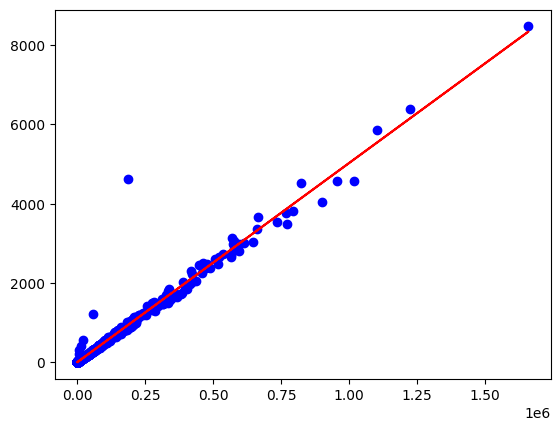

In [68]:
plt.scatter(X_test, y=y_test, color='blue')
plt.plot(X_test, m1.predict(X_test), color='red') # m1 is our best fit model

#### Inferencing

In [69]:
input_data = {"Dollars": [18500, 9000],}
df = pd.DataFrame(input_data)

In [70]:
m1.predict(df)

array([97.78868161, 50.14455838])